In [14]:
import networkx as nx
import numpy as np
import re
import matplotlib.pyplot as plt
from graphviz import Digraph

In [15]:
nx.__version__

'3.2'

In [16]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [17]:
a = "aaaa    aa  aaa   aaa     aaaa b a    c b"

# Split on 2 or more literal spaces
re.split(r' {2,}', a)


['aaaa', 'aa', 'aaa', 'aaa', 'aaaa b a', 'c b']

In [18]:
def transition(inp_file):

  with open(inp_file, "r") as fp:
    inp_data = fp.read()

  inp_data = inp_data.split("\n")
  print(inp_data)

  num_of_rows = len(inp_data)
  n = int(inp_data[0].strip())
  print(f"n = {n}")

  link_counts = [[0 for j in range(n)] for i in range(n)]
  out_degrees = [0 for i in range(n)]
  all_dir_edges = []

  # print(inp_data)
  for iter_row in range(1, num_of_rows):
    row_data = inp_data[iter_row].strip()
    # print(row_data)
    
    # for pair in row_data.split("  "):
    if n == 5:
      for pair in re.split(r' {2,4}', row_data):
        # print(f"pair", pair)
        i, j = [int(val) for val in re.split(r' ', pair)]
      
        out_degrees[i] += 1
        link_counts[i][j] += 1
        all_dir_edges += [[i, j]]
    elif n == 50:
      for pair in re.split(r' {3,}', row_data):
        # print(f"pair", pair)
        i, j = [int(val) for val in re.split(r' {1,2}', pair)]
      
        out_degrees[i] += 1
        link_counts[i][j] += 1
        all_dir_edges += [[i, j]]
  
  print(f"out_degrees", out_degrees)
  # print(f"link_counts", link_counts)

  transition_matrix = [[0 for j in range(n)] for i in range(n)]

  for i in range(n):
    # Write probability distribnution for row i.
    for j in range(n):
      # Write probability or coluimn j.
      p = (0.9 * link_counts[i][j] / out_degrees[i]) + (0.1 / n)
      transition_matrix[i][j] = p
    
  return transition_matrix, all_dir_edges


Small case ($5 \times 5$)

In [19]:
transition_matrix, all_dir_edges = transition("./tiny.txt")
transition_matrix

['5', '0 1', '1 2  1 2', '1 3  1 3  1 4', '2 3', '3 0', '4 0  4 2']
n = 5
out_degrees [1, 5, 1, 1, 2]


[[0.02, 0.92, 0.02, 0.02, 0.02],
 [0.02, 0.02, 0.38, 0.38, 0.19999999999999998],
 [0.02, 0.02, 0.02, 0.92, 0.02],
 [0.92, 0.02, 0.02, 0.02, 0.02],
 [0.47000000000000003, 0.02, 0.47000000000000003, 0.02, 0.02]]

In [24]:
def draw_cumulative_prob(transition_matrix, selected_row):
  transition_row = transition_matrix[selected_row]

  fig, ax = plt.subplots()

  height = 0.02
  line_color = "k"

  cumulative_prob = 0
  for prob in transition_row:
    ax.plot([cumulative_prob, cumulative_prob], [-height, height], color=line_color)
    cumulative_prob += prob

  ax.plot([cumulative_prob, cumulative_prob], [-height, height], color=line_color)

  ax.axhline(color=line_color)

  ax.axis("off")
  # ax.set_xticks([])
  # ax.set_yticks([])

  ax.set_aspect("equal")
  ax.set_xlim([-0.005, 1.005])
  plt.show(fig)

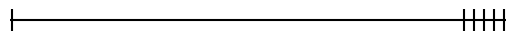

In [28]:
selected_row = 3
draw_cumulative_prob(transition_matrix, selected_row)

Large case ($50 \times 50$)

['50', ' 0  7    0 34   ', ' 1 14    1 22    1 22    1 45', ' 2 19    2 25    2 33 ', ' 3  4    3 17    3 27    3 36    3 42', ' 4 17    4 17    4 27    4 27', ' 5 43', ' 6 13    6 13    6 28', ' 7 41', ' 8 19    8 48', ' 9 11    9 30    9 46', '10  0   10  7   10 28   10 28   10 28   10 29   10 29   10 41', '11 21   11 30', '12  9   12 11   12 21   12 21   12 26   12 26', '13 22   13 23   13 47', '14  8   14 48', '15 34   15 49', '16  9', '17 20   17 24   17 38', '18  6   18 28   18 32   18 42', '19 15   19 40', '20  3   20 35   20 36   20 46', '21  1   21 14   21 22', '22  6 ', '23 11   23 21   23 22', '24  4   24  5   24 38', '25 34', '26  9   26 16   26 48', '27  5   27 24   27 31', '28 22   28 39   28 44', '29 49   29 22', '30 23   30 37', '31 18   31 32', '32  5   32  6   32 13   32 27   32 37   32 47', '33  8   33 19', '34  2   34 19   34 40', '35  9   35 46', '36 42', '37  5   37 9    37 35   37 35   37 47', '38 35   38 37', '39 18   39 42', '40 15', '41 28   41 44', '42 31', '

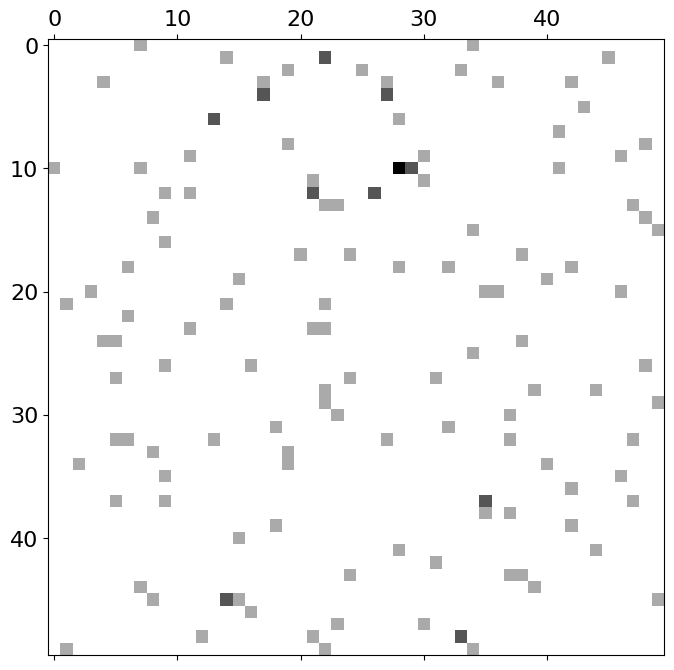

In [8]:
transition_matrix, all_dir_edges = transition("./large.txt")

fig, ax = plt.subplots(figsize=(8, 8))

n = len(transition_matrix)
link_counts = [[0 for j in range(n)] for i in range(n)]
for edge in all_dir_edges:
  link_counts[edge[0]][edge[1]] += 1

ax.matshow(link_counts, cmap="gray_r")

plt.show(fig)

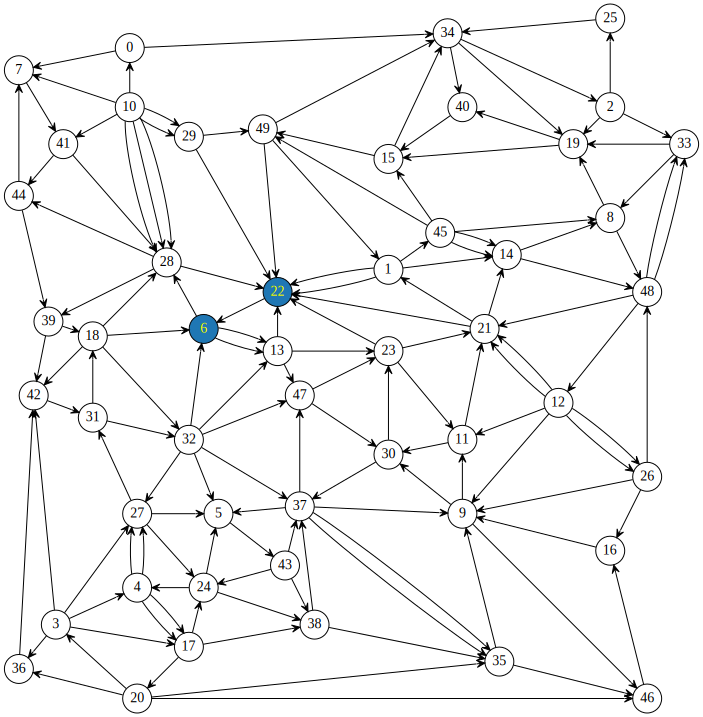

In [9]:
# T = Digraph(engine="dot")
# T.attr('node', shape="circle", fixedsize="true", height="0.4")
# T.attr("graph", overlap="false", splines="true")

T = Digraph(engine="neato")
T.attr('node', shape="circle", fixedsize="true", height="0.4")
T.attr("graph", overlap="scalexy", splines="line")

pos = {
    0: (20, 93), 1: (55, 63), 2: (85, 85), 3: (10, 15), 4: (21, 20),
    5: (32, 30), 6: (30, 55), 7: (5, 90), 8: (85, 70), 9: (65, 30),
    10: (20, 85), 11: (65, 40), 12: (78, 45), 13: (40, 52), 14: (71, 65),
    15: (55, 78), 16: (85, 25), 17: (28, 12), 18: (15, 54), 19: (80, 80),
    20: (21, 5), 21: (68, 55), 22: (40, 60), 23: (55, 52), 24: (30, 20),
    25: (85, 97), 26: (90, 35), 27: (21, 30), 28: (25, 64), 29: (28, 81),
    30: (55, 38), 31: (15, 43), 32: (28, 40), 33: (95, 80), 34: (63, 95),
    35: (70, 10), 36: (5, 9), 37: (43, 31), 38: (45, 15), 39: (9, 56),
    40: (65, 85), 41: (11, 80), 42: (7, 46), 43: (41, 23), 44: (5, 73),
    45: (62, 68), 46: (90, 5), 47: (43, 46), 48: (90, 60), 49: (38, 82)
}

highest_nodes = [6, 22]

drawn_node = []
scale = 10
for edge in all_dir_edges:
  node_from, node_to = edge
  if node_from not in drawn_node:
    drawn_node += [node_from]
    node_pos = pos[node_from]
    
    if node_from in highest_nodes:
      T.node(f"{node_from}", pos=f"{node_pos[0]/scale},{node_pos[1]/scale}!",
        style="filled", fillcolor="#1f77b4", fontcolor="yellow")
    else:
      T.node(f"{node_from}", pos=f"{node_pos[0]/scale},{node_pos[1]/scale}!")
  
  if node_to not in drawn_node:
    drawn_node += [node_to]
    node_pos = pos[node_to]
    if node_to in highest_nodes:
      T.node(f"{node_to}", pos=f"{node_pos[0]/scale},{node_pos[1]/scale}!",
        style="filled", fillcolor="#1f77b4", fontcolor="yellow")
    else:
      T.node(f"{node_to}", pos=f"{node_pos[0]/scale},{node_pos[1]/scale}!")

  T.edge(f"{node_from}", f"{node_to}", arrowsize="0.8", arrowhead="vee", constraint="false")

T

In [10]:
def random_surfer(transition_matrix, moves, rng):

  n = len(transition_matrix)

  hits = [0 for i in range(n)]
  start_page = 0    # Start at page 0
  for i in range(moves):
    r = rng.random()
    total = 0.
    next_page = start_page
    for j in range(0, n):
      total += transition_matrix[start_page][j]
      if r < total:
        next_page = j
        start_page = next_page
        break

    hits[start_page] += 1

  # calculate page rank. It measures the ratio between how many times
  # a page visited by a user divided by the total moves of a user
  page_rank = [0 for i in range(n)]
  for i, v in enumerate(hits):
    page_rank[i] = v / moves

  return hits, page_rank

In [11]:
seed = 260308
rng = np.random.default_rng(seed)

moves = 1_000_000
hits, page_rank = random_surfer(transition_matrix, moves, rng)

In [12]:
argsort = np.argsort(page_rank)
argsort[-2:]

array([22,  6])

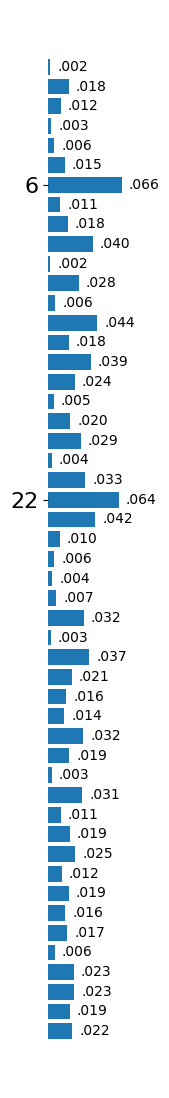

In [13]:
fig, ax = plt.subplots(figsize=(1, 14))

rects = ax.barh(range(len(page_rank)), page_rank)
labels = [f"{l:.3f}".lstrip("0") for l in page_rank]
ax.bar_label(rects, labels, label_type='edge', padding=5, rotation=0, 
             multialignment="right", fontsize=10) 

# only show the xticks for the highest and 2nd highest page rank
argsort = np.argsort(page_rank)
highest_nodes = argsort[-2:]

ax.set_yticks(highest_nodes)
ax.set_xticks([])
ax.invert_yaxis()
ax.spines[["top", "left", "bottom", "right"]].set_visible(False)

plt.show(fig)